In [15]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)


In [ ]:
from PIL import Image
import pywt
Image.MAX_IMAGE_PIXELS = None
# Replace with your image path

image_path = "scanner_dataset_students/s1_epson_4490/200/epson_4490_99.tif"

with Image.open(image_path) as img:
    width, height = img.size
    print(f"Dimensions: {width} x {height}")

In [59]:
import shutil
import os

src = os.path.join('..', 'datasets')
dst = os.getcwd()  # current directory: team28

for item in os.listdir(src):
    s = os.path.join(src, item)
    d = os.path.join(dst, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Done! Files copied:")
for item in os.listdir(src):
    print(f"  ✓ {item}")

Done! Files copied:
  ✓ scanner_dataset
  ✓ scanner_dataset_students


In [62]:
import os
print(sum(len(files) for _, _, files in os.walk("scanner_dataset")))

1583


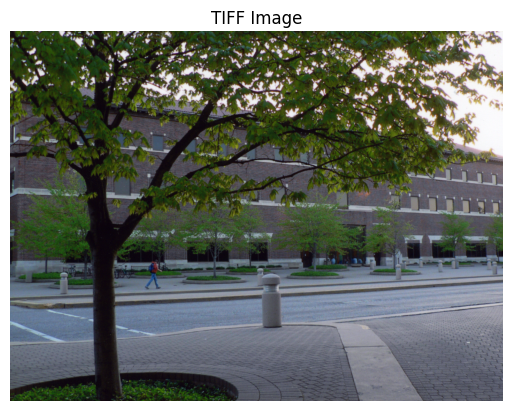

In [63]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "scanner_dataset/s1_epson_4490/200/epson_4490_1.tif"

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title("TIFF Image")
plt.show()

In [5]:
import numpy as np

def extract_patches(
    image,
    patch_size=(1024, 768),
    stride=(1024, 768)
):

    patches = []

    h, w = image.shape
    

    ph, pw = patch_size

    # -----------------------------------------------------
    # Skip image if smaller than patch size
    # -----------------------------------------------------

    if h < ph or w < pw:
        return patches

    # -----------------------------------------------------
    # Non-overlapping patch extraction
    # -----------------------------------------------------

    for i in range(0, h - ph + 1, stride[0]):

        for j in range(0, w - pw + 1, stride[1]):

            patch = image[i:i+ph, j:j+pw]

            # Safety check
            if patch.shape == (ph, pw):

                patches.append(patch)

    return patches

Skipped DPI folders: {'200'}
Total images loaded: 160
Sample path: scanner_dataset/s2_hp_scanjet_6300c_1_SG9CO270W5/1200/hp_scanjet_6300c_1_5.tif
Sample label: s2_hp_scanjet_6300c_1_SG9CO270W5


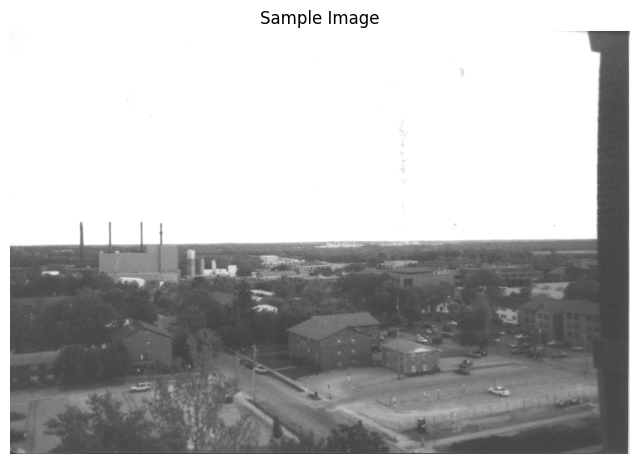


Unique labels found:
s1_epson_4490
s2_hp_scanjet_6300c_1_SG9CO270W5
s3_hp_scanjet_6300c_2
s4_hp_scanjet_8250

Total classes: 4


In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "scanner_dataset"
SKIP_SCANNERS = {"s5_mustek_1200_3_ep", "s6_visioneer_7300","s7_canon_lide_25","s8_canon_lide_700","s9_opticslim_2420","s10_visioneer_7100","s11_mustek_scanexpress_a3"}  # put exact folder names here

# Then add this check inside the scanner loop:
for scanner_name in os.listdir(dataset_path):
    
    if scanner_name in SKIP_SCANNERS:  # ← ADD THIS LINE
        continue
    
    scanner_folder = os.path.join(dataset_path, scanner_name)
    if not os.path.isdir(scanner_folder) or scanner_name.startswith("."):
        continue
# =========================================================
# DPI FOLDERS TO SKIP
# =========================================================

SKIP_DPI = {"200"}

# =========================================================
# STORAGE
# =========================================================

image_paths = []
labels = []

# Disable PIL protection for huge TIFFs
Image.MAX_IMAGE_PIXELS = None

# =========================================================
# DATASET TRAVERSAL
# =========================================================

for scanner_name in os.listdir(dataset_path):

    # Skip unwanted scanners
    if scanner_name in SKIP_SCANNERS:
        continue

    scanner_folder = os.path.join(dataset_path, scanner_name)

    # Skip hidden/system folders
    if not os.path.isdir(scanner_folder) or scanner_name.startswith("."):
        continue
    # -----------------------------------------------------
    # Traverse DPI folders
    # -----------------------------------------------------

    for dpi_folder in os.listdir(scanner_folder):

        # Skip unwanted DPI folders
        if dpi_folder in SKIP_DPI:
            continue

        dpi_path = os.path.join(scanner_folder, dpi_folder)

        if not os.path.isdir(dpi_path):
            continue

        # -------------------------------------------------
        # Traverse TIFF files
        # -------------------------------------------------

        for root, _, files in os.walk(dpi_path):

            for file in files:

                if file.lower().endswith((".tif", ".tiff")):

                    full_path = os.path.join(root, file)

                    image_paths.append(full_path)

                    # ONLY scanner label
                    labels.append(scanner_name)

# =========================================================
# CHECKS
# =========================================================

print(f"Skipped DPI folders: {SKIP_DPI}")

print(f"Total images loaded: {len(image_paths)}")

if len(image_paths) == 0:

    print("❌ No images found.")

else:

    print(f"Sample path: {image_paths[0]}")
    print(f"Sample label: {labels[0]}")

    # -----------------------------------------------------
    # Display sample image
    # -----------------------------------------------------

    img = Image.open(image_paths[0]).convert("L")

    plt.figure(figsize=(8,8))

    plt.imshow(img, cmap="gray")

    plt.title("Sample Image")
    plt.axis("off")

    plt.show()

# =========================================================
# VERIFY LABELS
# =========================================================

print("\nUnique labels found:")

for label in sorted(set(labels)):
    print(label)

print(f"\nTotal classes: {len(set(labels))}")

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_noise_nlm(image_path):
    # Load image (grayscale directly)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Convert to float
    img = img.astype(np.float32)
    
    # Denoising using Non-Local Means
   
    coeffs = pywt.wavedec2(patch.astype(np.float32), 'db8', level=4)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    coeffs[1:] = [tuple(pywt.threshold(d, sigma * np.sqrt(2 * np.log(d.size)), 'soft') for d in det) for det in coeffs[1:]]
    denoised = pywt.waverec2(coeffs, 'db8')[:patch.shape[0], :patch.shape[1]]
    noise = patch.astype(np.float32) - denoised
    denoised = denoised.astype(np.float32)
    
    # Noise extraction
    noise = img - denoised
    
    return img, denoised, noise

Estimating total patches...
Total estimated patches: 24270


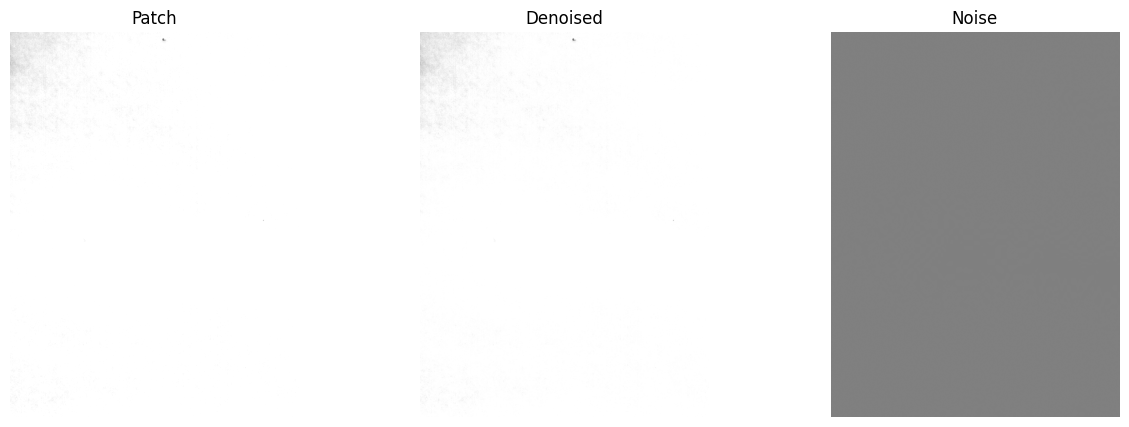

[Patch 24270/24270] Elapsed: 3023.3s | ETA: 0.0sss
✅ Done!
Total processed patches: 24270
Total noise samples: 24270
Total labels: 24270


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
import cv2

preview_done = False

all_noise = []
all_labels = []

start_time = time.time()

# =========================================================
# ESTIMATE TOTAL PATCHES
# =========================================================

total_patches = 0

print("Estimating total patches...")

for path in image_paths:

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    patches = extract_patches(img)

    total_patches += len(patches)

print(f"Total estimated patches: {total_patches}")

# =========================================================
# MAIN PROCESSING LOOP
# =========================================================

patch_counter = 0

for image_idx, (path, label) in enumerate(zip(image_paths, labels)):

    try:

        # =================================================
        # READ IMAGE
        # =================================================

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError("Image not readable")

        # =================================================
        # EXTRACT PATCHES
        # =================================================

        patches = extract_patches(img)

        # Skip image if no valid patches
        if len(patches) == 0:
            continue

        # =================================================
        # PROCESS EACH PATCH
        # =================================================

        for patch in patches:

            # ---------------------------------------------
            # DENOISING (NLM)
            # ---------------------------------------------

            import pywt
            coeffs = pywt.wavedec2(patch.astype(np.float32), 'db8', level=4)
            sigma = np.median(np.abs(coeffs[-1])) / 0.6745
            coeffs[1:] = [tuple(pywt.threshold(d, sigma * np.sqrt(2 * np.log(d.size)), 'soft') for d in det) for det in coeffs[1:]]
            denoised = pywt.waverec2(coeffs, 'db8')[:patch.shape[0], :patch.shape[1]]
            noise = patch.astype(np.float32) - denoised

            # ---------------------------------------------
            # STORE RESULTS
            # ---------------------------------------------

            all_noise.append(noise)
            all_labels.append(label)

            patch_counter += 1

            # ---------------------------------------------
            # SHOW ONLY ONE PREVIEW
            # ---------------------------------------------

            if not preview_done:

                plt.figure(figsize=(15,5))

                plt.subplot(1,3,1)
                plt.imshow(patch, cmap='gray')
                plt.title("Patch")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(denoised, cmap='gray')
                plt.title("Denoised")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(
                    noise,
                    cmap='gray',
                    vmin=-20,
                    vmax=20
                )

                plt.title("Noise")
                plt.axis("off")

                plt.show()

                preview_done = True

            # ---------------------------------------------
            # PATCH-LEVEL PROGRESS + ETA
            # ---------------------------------------------

            elapsed = time.time() - start_time

            avg_time = elapsed / patch_counter

            remaining = avg_time * (total_patches - patch_counter)

            print(
                f"[Patch {patch_counter}/{total_patches}] "
                f"Elapsed: {elapsed:.1f}s | "
                f"ETA: {remaining:.1f}s",
                end="\r"
            )

    except Exception as e:

        print(f"\n❌ Skipping {path}: {e}")

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n✅ Done!")

print(f"Total processed patches: {patch_counter}")
print(f"Total noise samples: {len(all_noise)}")
print(f"Total labels: {len(all_labels)}")

In [9]:
def get_row_pattern(noise):
    return np.mean(noise, axis=0)

In [10]:
all_row_patterns = []

for noise in all_noise:
    row_pattern = get_row_pattern(noise)
    all_row_patterns.append(row_pattern)

print("Total row patterns:", len(all_row_patterns))

Total row patterns: 24270


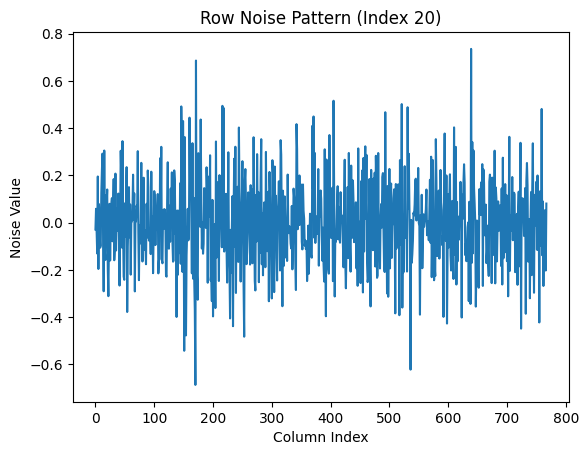

In [11]:
import matplotlib.pyplot as plt

preview_index = 20  # change this if needed

row_pattern = all_row_patterns[preview_index]

plt.plot(row_pattern)
plt.title(f"Row Noise Pattern (Index {preview_index})")
plt.xlabel("Column Index")
plt.ylabel("Noise Value")
plt.show()

In [12]:
import numpy as np
import scipy.stats as stats

def extract_16_features(noise):

    # =====================================================
    # STEP 1: Row pattern
    # =====================================================

    row_pattern = np.mean(noise, axis=0)

    # =====================================================
    # SET 1: Row pattern features
    # =====================================================

    f1 = np.mean(row_pattern)
    f2 = np.median(row_pattern)
    f3 = np.std(row_pattern)

    f4 = stats.skew(row_pattern)
    f5 = stats.kurtosis(row_pattern)

    f6 = np.min(row_pattern)
    f7 = np.max(row_pattern)

    f8 = np.sum(row_pattern ** 2)

    # =====================================================
    # STEP 2: Row correlations
    # =====================================================

    correlations = []

    row_pattern_std = np.std(row_pattern)

    # Skip invalid row pattern
    if row_pattern_std < 1e-8:

        correlations = [0]

    else:

        for row in noise:

            row_std = np.std(row)

            # Skip nearly constant rows
            if row_std < 1e-8:
                continue

            corr = np.corrcoef(row, row_pattern)[0, 1]

            # Keep only finite values
            if np.isfinite(corr):
                correlations.append(corr)

        # Prevent empty array
        if len(correlations) == 0:
            correlations = [0]

    correlations = np.array(correlations)

    # =====================================================
    # SET 2: Correlation features
    # =====================================================

    f9  = np.mean(correlations)
    f10 = np.median(correlations)
    f11 = np.std(correlations)

    f12 = stats.skew(correlations)
    f13 = stats.kurtosis(correlations)

    f14 = np.min(correlations)
    f15 = np.max(correlations)

    f16 = np.sum(correlations ** 2)

    # =====================================================
    # FINAL FEATURE VECTOR
    # =====================================================

    features = [
        f1, f2, f3, f4,
        f5, f6, f7, f8,
        f9, f10, f11, f12,
        f13, f14, f15, f16
    ]

    # Final cleanup
    features = np.nan_to_num(features)

    return features

In [13]:
import pandas as pd
import numpy as np
import time

# =========================================================
# FEATURE NAMES
# =========================================================

feature_names = [
    "Row Mean", "Row Median", "Row Std", "Row Skewness", "Row Kurtosis",
    "Row Min", "Row Max", "Row Energy",
    "Corr Mean", "Corr Median", "Corr Std", "Corr Skewness", "Corr Kurtosis",
    "Corr Min", "Corr Max", "Corr Energy"
]

# =========================================================
# STORAGE
# =========================================================

all_features = []
valid_labels = []
all_image_ids = [] 

preview_index = 1
preview_done = False
all_noise_valid = []   
skipped_count = 0

# =========================================================
# TIMER
# =========================================================

start_time = time.time()

total_samples = len(all_noise)

# =========================================================
# MAIN LOOP
# =========================================================

for i, (noise, label) in enumerate(zip(all_noise, all_labels)):

    try:

        # -------------------------------------------------
        # Extract features
        # -------------------------------------------------

        features = extract_16_features(noise)

        features = np.array(features, dtype=np.float32)

        # -------------------------------------------------
        # Skip invalid feature vectors
        # -------------------------------------------------

        if np.any(np.isnan(features)):
            skipped_count += 1
            continue

        if np.any(np.isinf(features)):
            skipped_count += 1
            continue

        # -------------------------------------------------
        # Store valid sample
        # -------------------------------------------------

        all_features.append(features)
        all_noise_valid.append(noise)
        valid_labels.append(label)
        all_image_ids.append(i)

        # -------------------------------------------------
        # Show ONE preview
        # -------------------------------------------------

        if not preview_done and len(all_features) > preview_index:

            print("Feature length:", len(features))

            for name, value in zip(feature_names, features):
                print(f"{name:20s}: {value:.6f}")

            df = pd.DataFrame({
                "Feature": feature_names,
                "Value": features
            })

            display(df)

            preview_done = True

        # -------------------------------------------------
        # PROGRESS + ETA
        # -------------------------------------------------

        elapsed = time.time() - start_time

        avg_time = elapsed / (i + 1)

        remaining = avg_time * (total_samples - i - 1)

        print(
            f"[{i+1}/{total_samples}] "
            f"Valid: {len(all_features)} | "
            f"Skipped: {skipped_count} | "
            f"Elapsed: {elapsed:.1f}s | "
            f"ETA: {remaining:.1f}s",
            end="\r"
        )

    except Exception as e:

        skipped_count += 1

        print(f"\n❌ Skipping sample {i}: {e}")

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n✅ Feature extraction complete")

print(f"Valid feature vectors : {len(all_features)}")
print(f"Valid labels          : {len(valid_labels)}")
print(f"Skipped samples       : {skipped_count}")

Feature length: 16 | Skipped: 0 | Elapsed: 0.1s | ETA: 2057.2s
Row Mean            : -0.000044
Row Median          : -0.000045
Row Std             : 0.000007
Row Skewness        : 0.267185
Row Kurtosis        : 0.212863
Row Min             : -0.000062
Row Max             : -0.000023
Row Energy          : 0.000002
Corr Mean           : 0.203208
Corr Median         : 0.251039
Corr Std            : 0.193954
Corr Skewness       : -0.843544
Corr Kurtosis       : -0.049277
Corr Min            : -0.346945
Corr Max            : 0.508686
Corr Energy         : 80.805534


,Feature,Value
0,Row Mean,-0.000044
1,Row Median,-0.000045
2,Row Std,0.000007
3,Row Skewness,0.267185
4,Row Kurtosis,0.212863
5,Row Min,-0.000062
6,Row Max,-0.000023
7,Row Energy,0.000002
8,Corr Mean,0.203208
9,Corr Median,0.251039


[24270/24270] Valid: 24270 | Skipped: 0 | Elapsed: 2003.4s | ETA: 0.0ssss
✅ Feature extraction complete
Valid feature vectors : 24270
Valid labels          : 24270
Skipped samples       : 0


In [14]:
def compute_pce(noise, reference):
    # Cross-correlation in frequency domain
    F1 = np.fft.fft2(noise)
    F2 = np.fft.fft2(reference)
    cross_corr = np.fft.ifft2(F1 * np.conj(F2)).real
    
    peak = np.max(cross_corr)
    # Energy excluding peak location
    peak_pos = np.unravel_index(np.argmax(cross_corr), cross_corr.shape)
    mask = np.ones_like(cross_corr, dtype=bool)
    mask[peak_pos] = False
    energy = np.mean(cross_corr[mask] ** 2)
    
    pce = (peak ** 2) / energy if energy > 0 else 0
    return pce

In [15]:
import numpy as np

X = np.array(all_features)   # shape: (N, 16)
y = np.array(valid_labels)     # scanner labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24270, 16)
y shape: (24270,)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
groups = np.array(all_image_ids)

print("Classes:", le.classes_)

Classes: ['s1_epson_4490' 's2_hp_scanjet_6300c_1_SG9CO270W5'
 's3_hp_scanjet_6300c_2' 's4_hp_scanjet_8250']


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
import numpy as np

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_scaled, y_encoded, groups=groups))

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train samples:", len(X_train))
print("Test samples :", len(X_test))

Train samples: 19416
Test samples : 4854


In [19]:
from collections import defaultdict

# Group training noises by scanner label
scanner_noises = defaultdict(list)
for idx in train_idx:
    scanner_noises[valid_labels[idx]].append(all_noise_valid[idx])

# Average noise per scanner → reference SPN
reference_spn = {}
for scanner, noises in scanner_noises.items():
    reference_spn[scanner] = np.mean(noises, axis=0)

In [20]:
def add_reference_features(noise, reference_spn):
    extra = []
    for scanner, ref in reference_spn.items():
        # Resize ref if shapes differ
        if ref.shape != noise.shape:
            ref = cv2.resize(ref, (noise.shape[1], noise.shape[0]))
        corr = np.corrcoef(noise.flatten(), ref.flatten())[0, 1]
        extra.append(corr if np.isfinite(corr) else 0.0)
    return extra

# Rebuild X with extra features

X_enhanced = []
for i, (noise, feat) in enumerate(zip(all_noise_valid, all_features)):
    ref_feats = add_reference_features(noise, reference_spn)
    X_enhanced.append(np.concatenate([feat, ref_feats]))

X_scaled = scaler.fit_transform(np.array(X_enhanced))

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# Use GroupKFold to avoid leakage during CV too
from sklearn.model_selection import GroupKFold

cv = GroupKFold(n_splits=5)

# ── STAGE 1: Coarse search ──────────────────────────────
param_grid_coarse = {
    'C':     [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

grid_coarse = GridSearchCV(
    SVC(),
    param_grid_coarse,
    cv=cv.split(X_train, y_train, groups=groups[train_idx]),
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)
grid_coarse.fit(X_train, y_train)

print("✅ Best coarse params:", grid_coarse.best_params_)
print("✅ Best coarse CV score:", round(grid_coarse.best_score_, 4))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END ........................C=1, gamma=1, kernel=linear; total time=   9.7s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   6.9s
[CV] END ....................C=100, gamma=0.0001, kernel=rbf; total time=   8.9s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=  25.4s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=  16.5s
[CV] END ....................C=100, gamma=0.0001, kernel=rbf; total time=   9.1s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=  16.5s
[CV] END ....................C=100, gamma=0.0001, kernel=rbf; total time=   9.2s
[CV] END .....................C=0.01, gamma=0.01, kernel=rbf; total time=  16.3s
[CV] END ....................C=100, gamma=0.0001, kernel=rbf; total time=   9.2s
[CV] END .................C=0.01, gamma=0.001, kernel=linear; total time=   6.1s
[CV] END .......................C=1, gamma=0.00

In [22]:
# ── STAGE 2: Fine search around best coarse params ─────
best_C     = grid_coarse.best_params_['C']
best_gamma = grid_coarse.best_params_['gamma']
best_kernel = grid_coarse.best_params_['kernel']

# Only fine-tune gamma if kernel is rbf
if best_kernel == 'rbf':
    param_grid_fine = {
        'C':      [best_C / 5, best_C, best_C * 5],
        'gamma':  [best_gamma / 5, best_gamma, best_gamma * 5],
        'kernel': [best_kernel]
    }
else:
    param_grid_fine = {
        'C':      [best_C / 5, best_C, best_C * 5],
        'kernel': ['linear']
    }

grid_fine = GridSearchCV(
    SVC(),
    param_grid_fine,
    cv=cv.split(X_train, y_train, groups=groups[train_idx]),
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)
grid_fine.fit(X_train, y_train)

print("✅ Best fine params:", grid_fine.best_params_)
print("✅ Best fine CV score:", round(grid_fine.best_score_, 4))

model = grid_fine.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits
✅ Best fine params: {'C': 50, 'gamma': 0.1, 'kernel': 'rbf'}
✅ Best fine CV score: 0.884


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

y_pred = model.predict(X_test)

print("=" * 50)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Best CV Score : {grid_fine.best_score_:.4f}")
print(f"Best Params   : {grid_fine.best_params_}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix as DataFrame for readability
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\nConfusion Matrix:")
print(cm_df)

Test Accuracy : 0.8844
Best CV Score : 0.8840
Best Params   : {'C': 50, 'gamma': 0.1, 'kernel': 'rbf'}

Classification Report:
                                  precision    recall  f1-score   support

                   s1_epson_4490       0.90      0.96      0.93      2111
s2_hp_scanjet_6300c_1_SG9CO270W5       0.57      0.48      0.52       362
           s3_hp_scanjet_6300c_2       0.67      0.59      0.62       543
              s4_hp_scanjet_8250       0.97      0.96      0.97      1838

                        accuracy                           0.88      4854
                       macro avg       0.78      0.75      0.76      4854
                    weighted avg       0.88      0.88      0.88      4854


Confusion Matrix:
                                  s1_epson_4490  \
s1_epson_4490                              2033   
s2_hp_scanjet_6300c_1_SG9CO270W5             71   
s3_hp_scanjet_6300c_2                       101   
s4_hp_scanjet_8250                           47   

   

In [26]:
import os
from PIL import Image
from collections import Counter
import pandas as pd

# =========================================================
# SETTINGS
# =========================================================

dataset_path = "scanner_dataset"
TARGET_DPI = {"1200", "4800"}

# Disable PIL large-image protection
Image.MAX_IMAGE_PIXELS = None

# =========================================================
# COLLECT IMAGE SIZES
# =========================================================

size_list = []

for scanner_name in os.listdir(dataset_path):

    scanner_folder = os.path.join(dataset_path, scanner_name)

    if not os.path.isdir(scanner_folder) or scanner_name.startswith("."):
        continue

    # -----------------------------------------------------
    # Only use 200 DPI folder
    # -----------------------------------------------------

    for dpi in TARGET_DPI:
        dpi_folder = os.path.join(scanner_folder, dpi)
        if not os.path.isdir(dpi_folder):
            continue

    # -----------------------------------------------------
    # Traverse TIFF files
    # -----------------------------------------------------

    for root, _, files in os.walk(dpi_folder):

        for file in files:

            if file.lower().endswith((".tif", ".tiff")):

                path = os.path.join(root, file)

                try:
                    with Image.open(path) as img:

                        width, height = img.size

                        # Store as tuple
                        size_list.append((width, height))

                except Exception as e:

                    print(f"❌ Error reading {path}: {e}")

# =========================================================
# FREQUENCY COUNT
# =========================================================

size_counts = Counter(size_list)

# =========================================================
# CONVERT TO DATAFRAME
# =========================================================

df = pd.DataFrame(
    [
        {
            "Width": size[0],
            "Height": size[1],
            "Count": count
        }
        for size, count in size_counts.items()
    ]
)

# Sort by frequency
df = df.sort_values(by="Count", ascending=False)

# Reset index
df = df.reset_index(drop=True)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print(f"\nTotal unique image sizes: {len(df)}\n")

print(df)


Total unique image sizes: 58

    Width  Height  Count
0    7200    4860     40
1    7272    4876     32
2    7248    4776     18
3    6970    4750     12
4    7026    4750     12
5    7026    4863      9
6    7026    4807      9
7    6913    4807      7
8    7083    4863      7
9    6913    4750      6
10   7248    4896      6
11   7248    4728      6
12   6970    4807      6
13   7083    4750      5
14   7272    4920      5
15   7026    4694      5
16   6970    4694      5
17   7140    4807      4
18   6913    4637      4
19   6856    4694      3
20   7083    4807      3
21   6964    4700      3
22   7248    4944      3
23   6864    4600      2
24   7196    4750      2
25   6932    4700      2
26   7140    4863      2
27   6913    4694      2
28   6970    4581      2
29   6970    4637      2
30   7536    4920      2
31   6970    4863      2
32   6856    4581      1
33   6856    4807      1
34   6864    4332      1
35   6964    4732      1
36   7000    4732      1
37   6970    5033  

In [27]:
noise_by_scanner = {}

for noise, label in zip(all_noise, all_labels):
    noise_by_scanner.setdefault(label, []).append(noise)

In [28]:
ref_patterns_2D = {}

for label, noises in noise_by_scanner.items():
    ref_patterns_2D[label] = np.mean(noises, axis=0)

In [29]:
from sklearn.model_selection import train_test_split
import numpy as np

# =====================================================
# SPLIT NOISE + LABELS
# =====================================================

train_noise, test_noise, train_labels, test_labels = train_test_split(
    all_noise,
    all_labels,
    test_size=0.3,
    random_state=42,
    stratify=all_labels
)

print("Train samples:", len(train_noise))
print("Test samples :", len(test_noise))

Train samples: 16989
Test samples : 7281


In [30]:
# =====================================================
# BUILD REFERENCE PATTERNS
# =====================================================

reference_patterns = {}

unique_scanners = sorted(set(train_labels))

for scanner in unique_scanners:

    # Collect residuals for this scanner
    scanner_noises = [
        noise
        for noise, label in zip(train_noise, train_labels)
        if label == scanner
    ]

    # Average residuals
    reference = np.mean(scanner_noises, axis=0)

    reference_patterns[scanner] = reference

print("Reference patterns created:")
print(reference_patterns.keys())

Reference patterns created:
dict_keys(['s1_epson_4490', 's2_hp_scanjet_6300c_1_SG9CO270W5', 's3_hp_scanjet_6300c_2', 's4_hp_scanjet_8250'])


In [31]:
def compute_correlation(a, b):

    a_flat = a.flatten()
    b_flat = b.flatten()

    # Avoid divide-by-zero
    if np.std(a_flat) < 1e-8:
        return 0

    if np.std(b_flat) < 1e-8:
        return 0

    corr = np.corrcoef(a_flat, b_flat)[0,1]

    if np.isnan(corr):
        return 0

    return corr

In [32]:
predictions = []

for noise in test_noise:

    best_scanner = None
    best_corr = -999

    # Compare against each reference pattern
    for scanner, ref_pattern in reference_patterns.items():

        corr = compute_correlation(noise, ref_pattern)

        if corr > best_corr:

            best_corr = corr
            best_scanner = scanner

    predictions.append(best_scanner)

In [33]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =====================================================
# ACCURACY
# =====================================================

accuracy = accuracy_score(test_labels, predictions)

print("Accuracy:", accuracy)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report:\n")

print(
    classification_report(
        test_labels,
        predictions
    )
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(test_labels, predictions)

print("\nConfusion Matrix:\n")

print(cm)

Accuracy: 0.6718857299821454

Classification Report:

                                  precision    recall  f1-score   support

                   s1_epson_4490       0.90      0.52      0.66      3110
s2_hp_scanjet_6300c_1_SG9CO270W5       0.36      0.53      0.43       577
           s3_hp_scanjet_6300c_2       0.44      0.45      0.44       802
              s4_hp_scanjet_8250       0.68      0.93      0.79      2792

                        accuracy                           0.67      7281
                       macro avg       0.60      0.61      0.58      7281
                    weighted avg       0.72      0.67      0.67      7281


Confusion Matrix:

[[1629  312  318  851]
 [  42  307  108  120]
 [  75  140  364  223]
 [  67   88   45 2592]]


In [34]:
from sklearn.model_selection import train_test_split

train_noise, test_noise, train_labels, test_labels = train_test_split(
    all_noise,
    all_labels,
    test_size=0.3,
    random_state=42,
    stratify=all_labels
)

print("Train samples:", len(train_noise))
print("Test samples :", len(test_noise))

Train samples: 16989
Test samples : 7281


In [35]:
import numpy as np

def get_row_pattern(noise):

    # Average across rows
    row_pattern = np.mean(noise, axis=0)

    return row_pattern

In [36]:
reference_patterns_1d = {}

unique_scanners = sorted(set(train_labels))

for scanner in unique_scanners:

    scanner_patterns = []

    for noise, label in zip(train_noise, train_labels):

        if label == scanner:

            row_pattern = get_row_pattern(noise)

            scanner_patterns.append(row_pattern)

    # Average 1D patterns
    reference = np.mean(scanner_patterns, axis=0)

    reference_patterns_1d[scanner] = reference

print("1D reference patterns created")

1D reference patterns created


In [37]:
def compute_1d_correlation(a, b):

    a = a.astype(np.float32)
    b = b.astype(np.float32)

    a = a - np.mean(a)
    b = b - np.mean(b)

    std_a = np.std(a)
    std_b = np.std(b)

    if std_a < 1e-8:
        return 0

    if std_b < 1e-8:
        return 0

    a = a / std_a
    b = b / std_b

    corr = np.mean(a * b)

    return corr

In [38]:
import time

predictions = []

start_time = time.time()

total_tests = len(test_noise)

for i, noise in enumerate(test_noise):

    # Extract 1D row fingerprint
    row_pattern = get_row_pattern(noise)

    best_scanner = None
    best_corr = -999

    # Compare against each reference
    for scanner, ref_pattern in reference_patterns_1d.items():

        corr = compute_1d_correlation(
            row_pattern,
            ref_pattern
        )

        if corr > best_corr:

            best_corr = corr
            best_scanner = scanner

    predictions.append(best_scanner)

    # -------------------------------------------------
    # Progress + ETA
    # -------------------------------------------------

    elapsed = time.time() - start_time

    avg_time = elapsed / (i + 1)

    remaining = avg_time * (total_tests - i - 1)

    print(
        f"[{i+1}/{total_tests}] "
        f"Elapsed: {elapsed:.1f}s | "
        f"ETA: {remaining:.1f}s",
        end="\r"
    )

print("\n✅ Classification complete")

[7281/7281] Elapsed: 11.8s | ETA: 0.0s
✅ Classification complete


In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =====================================================
# ACCURACY
# =====================================================

accuracy = accuracy_score(test_labels, predictions)

print("Accuracy:", accuracy)

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report:\n")

print(
    classification_report(
        test_labels,
        predictions
    )
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(test_labels, predictions)

print("\nConfusion Matrix:\n")

print(cm)

Accuracy: 0.7030627661035572

Classification Report:

                                  precision    recall  f1-score   support

                   s1_epson_4490       0.91      0.57      0.70      3110
s2_hp_scanjet_6300c_1_SG9CO270W5       0.33      0.59      0.42       577
           s3_hp_scanjet_6300c_2       0.46      0.60      0.52       802
              s4_hp_scanjet_8250       0.77      0.91      0.83      2792

                        accuracy                           0.70      7281
                       macro avg       0.62      0.66      0.62      7281
                    weighted avg       0.76      0.70      0.71      7281


Confusion Matrix:

[[1774  361  372  603]
 [  46  338  131   62]
 [  42  194  479   87]
 [  77  130   57 2528]]


Feature matrix shape: (24270, 16)
Explained variance ratio:
[0.38709405 0.19680355]


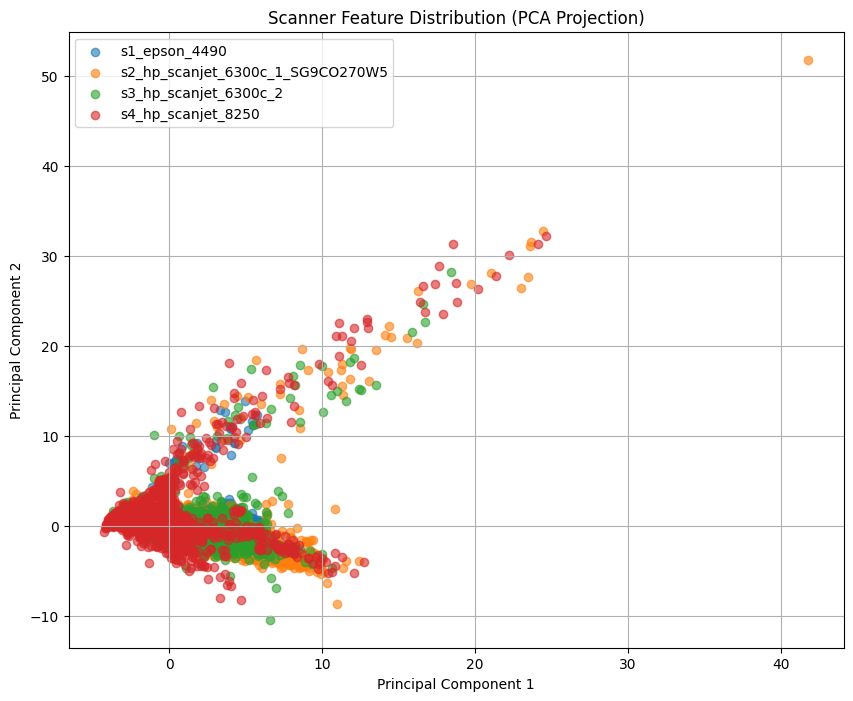

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =====================================================
# CONVERT TO NUMPY
# =====================================================

X = np.array(all_features)

y = np.array(valid_labels)

print("Feature matrix shape:", X.shape)

# =====================================================
# STANDARDIZE FEATURES
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================================
# PCA REDUCTION
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(10,8))

unique_labels = np.unique(y)

for label in unique_labels:

    idx = y == label

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=label,
        alpha=0.6
    )

# =====================================================
# LABELS
# =====================================================

plt.title("Scanner Feature Distribution (PCA Projection)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
!pip install seaborn

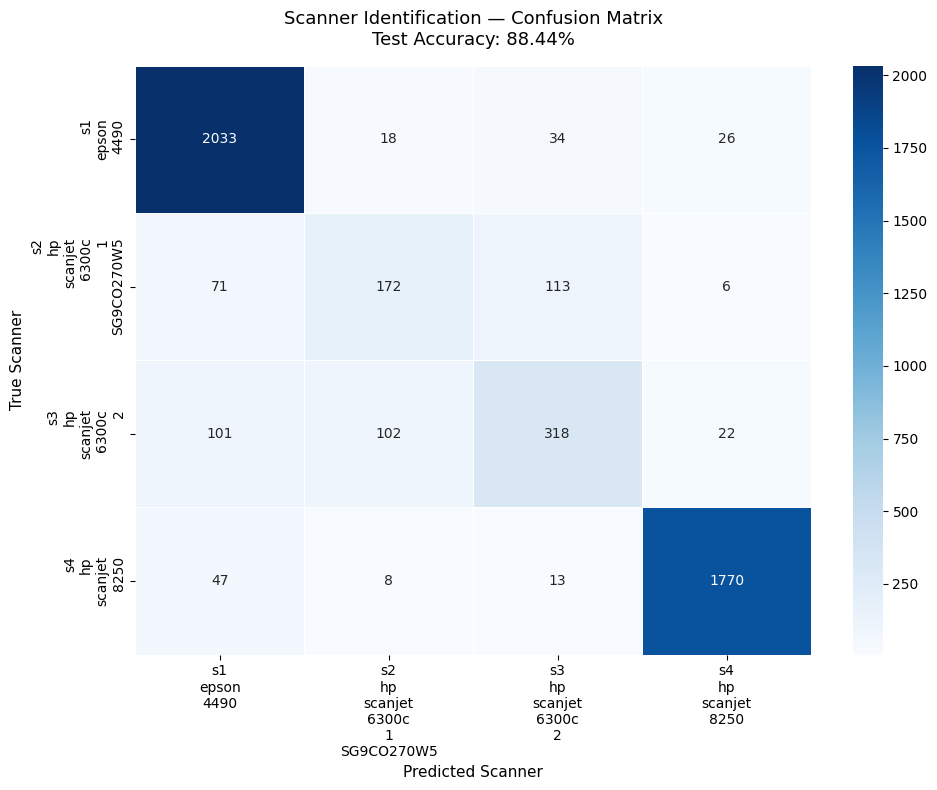

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Shorter class names for readability
short_names = [name.replace("_", "\n") for name in le.classes_]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5
)
plt.title(f'Scanner Identification — Confusion Matrix\nTest Accuracy: {accuracy_score(y_test, y_pred):.2%}', 
          fontsize=13, pad=15)
plt.ylabel('True Scanner', fontsize=11)
plt.xlabel('Predicted Scanner', fontsize=11)
plt.tight_layout()
plt.show()